## Actividad 3_6

<div style="border-style:groove;border-width:thin;padding:10px">

En esta actividad vamos a intentar solucionar un problema de regresión con uno de los métodos que hemos visto en clase hasta ahora:
- Regresión Lineal Simple.
- Regresión Lineal Múltiple.
- Regresión Polinómica.
</div>

<p style="border-style:groove;border-width:thin;padding:10px">
Lo primero que vamos a hacer es importar los datos y analizar el dataset que tenemos.
</p>

In [82]:
import pandas as pd

coches = pd.read_csv("CarPrice_Assignment.csv")

coches.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns


coches.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)[1:]

enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
highwaympg          0.697599
citympg             0.685751
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
car_ID              0.109093
peakrpm             0.085267
symboling           0.079978
stroke              0.079443
compressionratio    0.067984
Name: price, dtype: float64

<p style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a modificar el dataset para eliminar lo que no nos interesa y cambiar las columnas para poder hacer una regresión.
    
</p>

In [84]:
coches.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [85]:
coches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [86]:
coches['fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

In [87]:
coches = coches.drop(['car_ID'], axis=1)

In [88]:
coches.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [89]:
coches[['marca', 'modelo']] = coches['CarName'].str.split(' ', n=1, expand=True)

In [90]:
coches.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca,modelo
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,100 ls
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,100ls


In [91]:
coches = coches.drop(columns=['CarName', 'modelo'])
coches.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,marca
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [92]:
coches = pd.get_dummies(coches, dtype=int, columns=coches.select_dtypes(include=['object']).columns.difference(['doornumber']))

coches.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,marca_porsche,marca_renault,marca_saab,marca_subaru,marca_toyota,marca_toyouta,marca_vokswagen,marca_volkswagen,marca_volvo,marca_vw
0,3,two,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
1,3,two,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
2,1,two,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,0,0,0,0,0,0,0,0,0
3,2,four,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0
4,2,four,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0


In [93]:
coches["doornumber"] = coches["doornumber"].replace({
    "four": 4,
    "two": 2
}).astype(int)

coches.head()

/tmp/ipykernel_19401/3932056364.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coches["doornumber"] = coches["doornumber"].replace({


,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,marca_porsche,marca_renault,marca_saab,marca_subaru,marca_toyota,marca_toyouta,marca_vokswagen,marca_volkswagen,marca_volvo,marca_vw
0,3,2,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
1,3,2,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
2,1,2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,0,0,0,0,0,0,0,0,0
3,2,4,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0
4,2,4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0


In [94]:
coches.shape

(205, 80)

In [95]:
coches.columns

Index(['symboling', 'doornumber', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price', 'aspiration_std', 'aspiration_turbo', 'carbody_convertible',
       'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'carbody_wagon', 'cylindernumber_eight', 'cylindernumber_five',
       'cylindernumber_four', 'cylindernumber_six', 'cylindernumber_three',
       'cylindernumber_twelve', 'cylindernumber_two', 'drivewheel_4wd',
       'drivewheel_fwd', 'drivewheel_rwd', 'enginelocation_front',
       'enginelocation_rear', 'enginetype_dohc', 'enginetype_dohcv',
       'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'fuelsystem_1bbl', 'fuelsystem_2bbl',
       'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_mfi',
       'fuelsystem_mpfi', 'fuelsystem_spdi', 'fuelsystem_spfi',
       'fuelty

<div style="border-style:groove;border-width:thin;padding:10px">
    Ahora comprobamos si hay valores nulos. A continuación vamos a proceder a cambiar las columnas que tienen categorías ("categorical features") para poder realizar una regresión con ellas. 
<p>Antes que nada, vamos a definir que son columnas categóricas. Son columnas cuyos datos deben pertenecer a un conjunto de valores finito. Este conjunto de valores puede ser numérico (en cuyo caso podemos usarlo directamente en una regresión) o un texto.</p>
<p>Si nos encontramos con columnas con texto, como es nuestro caso, lo más común es asignar valores numéricos a los valores de las columnas. Esta técnica se llama <b>One-hot encoding</b>. El cambio más habitual para poder realizar una regresión sería convertir la columna en varias, una por cada posible valor. Usando como ejemplo nuestro dataset, la columna <b>fueltype</b> se transformaría en 2 columnas, <b>fueltype-gas y fueltype-diesel</b>.</p>
    <p>Los posibles valores de estas columnas dependeran de la codificación que usemos:</p>
    <ul>
        <li><b>Dummy encoding:</b> Tendrán 0 o 1. En nuestro caso de ejemplo, un coche diesel tendrá 0 en fueltype-gas y 1 en fueltype-diesel.</li>
        <li><b>Simple effect encoding:</b> En vez de 0 y 1 tendrán -0,25 y 0,75. En el mismo ejemplo, el coche diesel tendría -0,25 en fueltype-gas y 0,75 en fueltype-diesel.</li>
    </ul>    
    <p>La función <b>get_dummies</b> de pandas nos permite hacer este cambio en una columa o una lista de columnas. Vamos a hacer un ejemplo con una columna y, después, a moficiar las demás.</p>
</div>

In [96]:
coches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 80 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   doornumber             205 non-null    int64  
 2   wheelbase              205 non-null    float64
 3   carlength              205 non-null    float64
 4   carwidth               205 non-null    float64
 5   carheight              205 non-null    float64
 6   curbweight             205 non-null    int64  
 7   enginesize             205 non-null    int64  
 8   boreratio              205 non-null    float64
 9   stroke                 205 non-null    float64
 10  compressionratio       205 non-null    float64
 11  horsepower             205 non-null    int64  
 12  peakrpm                205 non-null    int64  
 13  citympg                205 non-null    int64  
 14  highwaympg             205 non-null    int64  
 15  price 

In [97]:
coches.corr(numeric_only=True)['price'].abs().sort_values(ascending=False)[1:]

enginesize             0.874145
curbweight             0.835305
horsepower             0.808139
carwidth               0.759325
cylindernumber_four    0.697762
                         ...   
fuelsystem_4bbl        0.017306
enginetype_ohcf        0.016285
cylindernumber_two     0.004544
enginetype_rotor       0.004544
fuelsystem_mfi         0.002747
Name: price, Length: 79, dtype: float64

In [99]:
from sklearn.model_selection import train_test_split

X = coches.drop('price', axis=1)
y = coches['price'].to_frame()


In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [102]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [103]:
X

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,marca_porsche,marca_renault,marca_saab,marca_subaru,marca_toyota,marca_toyouta,marca_vokswagen,marca_volkswagen,marca_volvo,marca_vw
0,3,2,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
1,3,2,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0,0,0,0,0,0,0,0,0,0
2,1,2,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0,0,0,0,0,0,0,0,0,0
3,2,4,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0
4,2,4,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,4,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,...,0,0,0,0,0,0,0,0,1,0
201,-1,4,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,...,0,0,0,0,0,0,0,0,1,0
202,-1,4,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,...,0,0,0,0,0,0,0,0,1,0
203,-1,4,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,...,0,0,0,0,0,0,0,0,1,0


In [104]:
y

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
200,16845.0
201,19045.0
202,21485.0
203,22470.0


In [105]:
lr.coef_

array([[ 1.42067820e+02,  6.00569053e+02,  3.20885501e+02,
        -1.72500502e+02,  6.08558539e+02, -2.01032905e+02,
         7.13373653e+00,  6.06348143e+01, -3.20923624e+03,
         3.98819408e+02, -9.93805074e+02, -1.51664993e+01,
         1.98221824e+00,  8.48816705e+01,  1.79795522e+01,
        -1.01624416e+03,  1.01624416e+03,  2.87624682e+03,
        -5.76324177e+02, -7.00104649e+02, -4.13639904e+02,
        -1.18617809e+03,  1.13417338e+03, -4.04396398e+03,
        -2.28982835e+03, -1.89640559e+03, -1.39834810e-11,
         5.37447448e+03,  1.72155006e+03, -1.22240546e+03,
        -1.14393952e+02,  1.33679941e+03, -6.14439513e+03,
         6.14439513e+03, -2.99751652e+02,  1.01181286e-11,
        -2.71494833e+03,  1.11322647e+02,  3.52678316e+03,
        -2.34495589e+03,  1.72155006e+03, -1.98116221e+03,
         7.12111715e+02, -2.01232036e+03,  4.00526497e+03,
        -6.80571763e+02,  4.36601027e+01, -1.10569317e+03,
         1.01871072e+03,  4.00526497e+03, -4.00526497e+0

In [106]:
lr.intercept_

array([-25522.19244633])

In [107]:
y_pred = lr.predict(X_test)

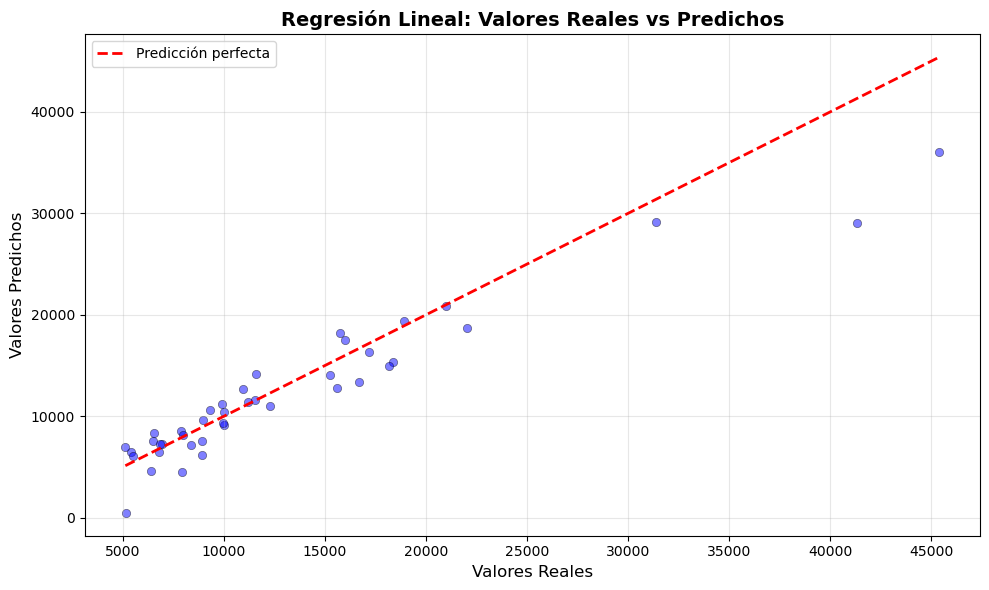

In [108]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores Reales', fontsize=12)
plt.ylabel('Valores Predichos', fontsize=12)
plt.title('Regresión Lineal: Valores Reales vs Predichos', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
from sklearn.metrics import mean_squared_error as MSE

In [110]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8813462471751785

<div style="border-style:groove;border-width:thin;padding:10px">
    Hay una columna categórica que tiene valores numéricos codificados en texto. En este caso he optado por modificarla y pasarla a un tipo de dato numérico aunque se podría hacer lo mismo que con las demás.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
    También se pueden modificar muchas columnas a la vez con el parámetro de get_dummies columns. En este caso no hay que especificar un prefix para que de nombre a las columnas. Pone por defecto el nombre de la columna original.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Para generar los conjuntos X e y vamos a eliminar price en X para coger solo esa columna en y.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a entrenar el sistema usando un modelo de regresión lineal. ¿Será suficiente? Vamos a usar todas las columnas. También se podría probar a usar un subconjunto de columnas.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
El resultado obtenido es 0.87 de R². Está bastante bien. El error cuadrático medio que estamos teniendo en el conjunto de test es de 3100€. Teniendo en cuenta el precio de un coche no parece un error pequeño. Vamos a intentar hacerlo mejor. 
    <p>Si habéis pintado las relaciones entre las distintas columnas habréis visto que hay algunas que parecen tener una relación polinómica con el precio. En concreto de grado 2. Vamos a probar con una regresión polinómica, de nuevo, con todas las columnas.</p>
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
¿Porqué sale tan mal? ¿Es dummy coding oportuno para lo que estamos haciendo?
El dummy encoding da valores de 0 y 1. El problema de estos valores es que 0 y 1 al cuadrado, al cubo, etc. no cambian de valor, luego hacer la regresión polinómica no tiene mucho sentido.
Vamos a probar con un "Simple effect encoding". Las columnas serán iguales pero en vez de valores de 0 y 1 tendremos -0.25 y 0.75. Para lograr esto simplemente restamos 0.25 a todas las columnas que hemos creado:
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a volver a hacer la regresión polinómica. A ver si esta vez obtenemos un resultado mejor que con la regresión lineal. La intuición en este caso nos indica que deberíamos obtener un resultado mejor ya que hay algunas variables que tienen relación de grado 2 con el precio.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Esta vez el R² es muy bueno y nos estamos equivocando de media 474€ en cada coche, lo cual es un dato de error bastante bueno. 
</div>